<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia representa uno de los pilares más importantes para el desarrollo socioeconómico del país. Con la transición y coexistencia de las plataformas SECOP I y SECOP II, se ha generado un volumen de información sin precedentes sobre cómo el Estado invierte sus recursos. Sin embargo, la complejidad y diversidad de estos datos exigen el uso de herramientas avanzadas de Analítica de Datos para transformar registros administrativos en conocimiento estratégico.

Este proyecto se enfoca en el estudio de los procesos de compra pública que han culminado en contratos efectivos. A través de técnicas de Aprendizaje Automático (Machine Learning), se busca descubrir patrones ocultos en las modalidades de selección, los tiempos de ejecución y la distribución de los presupuestos, permitiendo una visión técnica que aporte a la transparencia y a la eficiencia en la gestión pública

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

Objetivos Específicos
Realizar un Análisis Exploratorio de Datos (EDA) para identificar las tendencias de contratación por sectores, regiones y modalidades de selección.

Procesar y estandarizar la información integrada de SECOP I y II, gestionando la limpieza de datos faltantes y la codificación de variables categóricas.

Evaluar diferentes arquitecturas de modelos predictivos mediante el uso de herramientas de AutoML (como AutoGluon), con el fin de determinar el algoritmo que ofrezca mayor precisión en la clasificación o estimación de resultados contractuales.

Interpretar los resultados obtenidos para identificar qué variables (como cuantía, ubicación o tipo de entidad) tienen mayor peso en la configuración de un contrato exitoso.

<br>
VARIABLES OBSERVADAS
<br><br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **3. Carga de Datos:**

In [20]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy import stats
from sklearn.impute import SimpleImputer
from datetime import timedelta
#import scipy.stats as stats
#import statsmodels.api as sm
#import statsmodels.formula.api as smf
#import os
#from scipy.stats import chi2_contingency, pearsonr, kruskal

# Cargar el dataset optimizado
df = pd.read_parquet('datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


##### *Visualizar el df*

In [21]:
# Mostrar  5 filas aleatorias
df_aleatorio = df.sample(5)
df_aleatorio


,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
141134,Nacional,704142835,ICBF REGIONAL VALLE DEL CAUCA,899999239,Valle del Cauca,Cali,Modificado,Contratación régimen especial,BRINDAR ATENCIÓN A JOVENES QUE TIENEN UN PROCE...,BRINDAR ATENCIÓN A JOVENES QUE TIENEN UN PROCE...,Otro,2025-08-29T00:00:00.000,2025-09-01T00:00:00.000,2025-11-30T00:00:00.000,CO1.PCCNTR.8255690,76009362025,164410818,ALDEAS INFANTILES SOS COLOMBIA,https://community.secop.gov.co/Public/Tenderin...,SECOPII,NIT,860024041
279992,Nacional,702541384,DEFENSORÍA DEL PUEBLO,800186061,Distrito Capital de Bogotá,Bogotá,Aprobado,Contratación directa,Prestación de servicios profesionales de aboga...,Prestación de servicios profesionales de aboga...,Prestación de servicios,2025-11-26T00:00:00.000,NaN,2026-07-31T00:00:00.000,CO1.PCCNTR.8633497,CD-DP-6126-2025,43784000,LENIN ENRIQUE PARRA RENTERIA,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,11803250
26061,Territorial,700588080,IFC,800221777,Casanare,Yopal,Borrador,Contratación directa,NO DEFINIDO,Sin Descripcion,Prestación de servicios,NaN,NaN,2022-06-27T00:00:00.000,CO1.PCCNTR.3484593,CO1.PCCNTR.3484593,0,NO DEFINIDO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Sin Descripcion,No Definido
296736,Corporación Autónoma,706081700,CORPORACION AUTONOMA REGIONAL DE CUNDINAMARCA ...,899999062,Distrito Capital de Bogotá,No Definido,Aprobado,Contratación directa,Prestar servicios profesionales a la Dirección...,Prestar servicios profesionales a la Dirección...,Prestación de servicios,2025-11-28T00:00:00.000,NaN,2026-06-30T00:00:00.000,CO1.PCCNTR.8648486,CAR-CPS-3644-2025,63750000,Daniel Vidal Lopez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,80727842
251475,Territorial,704247485,MUNICIPIO DE SEVILLA,800100527,Valle del Cauca,Sevilla,En ejecución,Mínima cuantía,PRESTACIÓN DE SERVICIOS PARA REALIZAR EXÁMENES...,PRESTACIÓN DE SERVICIOS PARA REALIZAR EXÁMENES...,Prestación de servicios,2025-11-20T00:00:00.000,2025-11-20T00:00:00.000,2025-12-31T00:00:00.000,CO1.PCCNTR.8581793,SDB-2025-362,3249000,PROENSO SAS,https://community.secop.gov.co/Public/Tenderin...,SECOPII,NIT,900594645


OBSERVACION: 
1. Existe en la columna (estado_del_proceso) contratos que estan en estado borrador. lo que significa  que aun no están publicados oficialmente o no ha sido adjudicado o está en proceso de elaboración o revisión, por lo que carece de mucha de informacion en otras columnas, estas filas con este valor son candidatas a eliminar

2. Se debe realizar un tratamiento de datos que permita, cambiar los nombres de las columnas, pasar los datos a minúsculas, quitar tildes, convertir datos de tipo object a Date.

3. Se deben eliminar los contratos que tienen un valor de contrato en $ 0 pesos.


## **4. Tratamiento preliminar de datos**

In [22]:
#Esto nos deja solo con contratos que ya pasaron la etapa de creación inicial
df = df[df['estado_del_proceso'] != 'Borrador'].copy()
#Esto elimina los contratos que tienen valor $0
#df = df[df['valor_contrato'] != 0].copy()

# Obtener un resumen de la estructura del conjunto de datos:

print("\n*****TABLA CON TIPO DE VARIABLE, VALORES UNICOS Y VALORES FALTANTES*****\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


*****TABLA CON TIPO DE VARIABLE, VALORES UNICOS Y VALORES FALTANTES*****



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,str,7,0
1,codigo_entidad_en_secop,str,4893,0
2,nombre_de_la_entidad,str,5011,0
3,nit_de_la_entidad,str,4031,0
4,departamento_entidad,str,38,0
5,municipio_entidad,str,1077,0
6,estado_del_proceso,str,18,0
7,modalidad_de_contrataci_n,str,31,0
8,objeto_a_contratar,str,162100,0
9,objeto_del_proceso,str,169106,1


##### *Cambiar nombres de columnas*

In [23]:
#df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
                #   'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
        #  inplace=True)

##### *Cambiar tipo de dato 'Object' a 'Datetime'*

In [24]:
columnas_fechas = ['fecha_de_firma_del_contrato','fecha_inicio_ejecuci_n', 'fecha_fin_ejecuci_n']

for col in columnas_fechas:
    df[col] = pd.to_datetime(df[col])

# ANDRES SE DEBE COPIAR DESDE ACA HASTA LA GRAFICA VERDE DE LOS AÑOS

##### *Cambiar datos del dataset tipo dtype = 'str' a Minúsculas*

In [25]:
columnas_texto = ['documento_proveedor','nivel_entidad', 'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contrataci_n', 'objeto_a_contratar', 'objeto_del_proceso', 'tipo_de_contrato', 'numero_de_proceso', 'nom_raz_social_contratista', 'origen', 'tipo_documento_proveedor',   ]
for col in columnas_texto       :
        df[col] = df[col].str.lower().str.strip()

##### *Gráfica: Mapa valores faltantes*

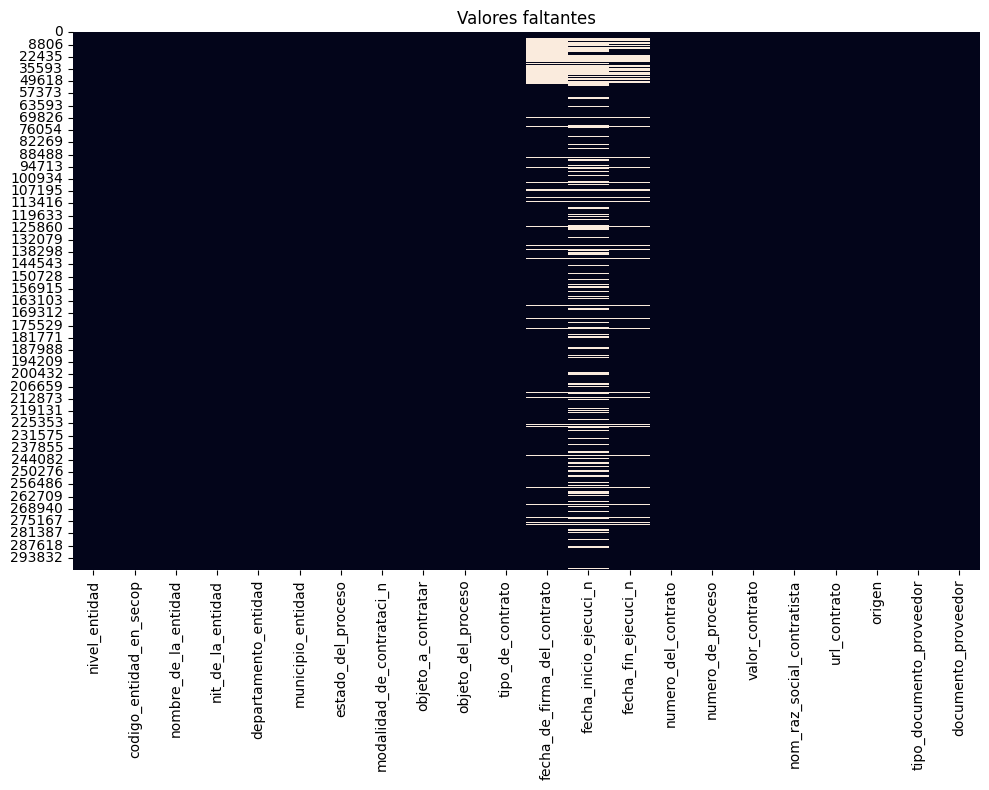

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.isna(), cbar=False)
plt.title("Valores faltantes")
plt.tight_layout()
plt.show()

##### *Gráfica: Porcentaje de FALTANTES O NAN*


=== GRÁFICO DE PORCENTAJES DE NAS POR COLUMNA ===


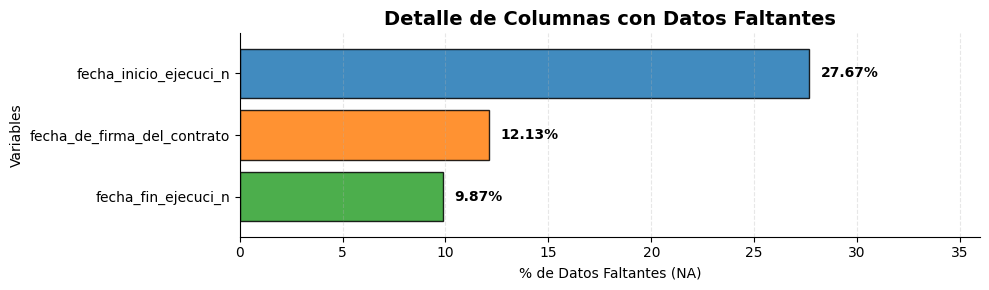

In [27]:
import matplotlib.pyplot as plt

# CALCULAR PORCENTAJE DE FALTANTES
print("\n=== GRÁFICO DE PORCENTAJES DE NAS POR COLUMNA ===")
faltantes = df.isna().mean().mul(100).sort_values(ascending=False).round(2)

# FILTRO: Solo columnas con más de 0% de nulos
faltantes_reales = faltantes[faltantes > 0.0]

if not faltantes_reales.empty:
    # 1. Definimos la paleta de colores
    # Usamos cm.get_cmap o simplemente plt.cm.tab10 para obtener variedad
    colores_nulos = plt.cm.tab10.colors 

    # Ajuste dinámico de altura
    dinamic_h = max(3, len(faltantes_reales) * 0.6)
    plt.figure(figsize=(10, dinamic_h))

    # 2. Graficamos pasando la lista de colores
    # Si hay más de 10 barras, los colores se repetirán automáticamente
    ax = faltantes_reales.plot(
        kind="barh", 
        color=colores_nulos, 
        width=0.8, 
        edgecolor='black',
        alpha=0.85
    )

    ax.set_xlabel("% de Datos Faltantes (NA)")
    ax.set_ylabel("Variables")
    ax.set_title("Detalle de Columnas con Datos Faltantes", fontsize=14, fontweight='bold')
    ax.invert_yaxis()

    # AJUSTE DE ESCALA
    max_val = faltantes_reales.max()
    plt.xlim(0, max_val * 1.3 if max_val > 0 else 10)

    # Añadir etiquetas de valor
    for i, v in enumerate(faltantes_reales):
        ax.text(v + (max_val * 0.02 if max_val > 0 else 0.1), i, f"{v}%",
                color='black', va='center', fontweight='bold')

    # Limpieza estética: quitamos bordes innecesarios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("¡Genial! No se encontraron valores faltantes en ninguna columna.")


### *Observación: indica que tenemos varios faltantes identificados en el MAPA y en la gráfica de barras, en el caso de fecha inicio de ejecución y fecha firma de contrato, estos datos se pueden imputar para quitar los nulos, con las fechas de inicio y firma que suelen ser las mismas*

##### *Gráfica: Variable Cualitativas*

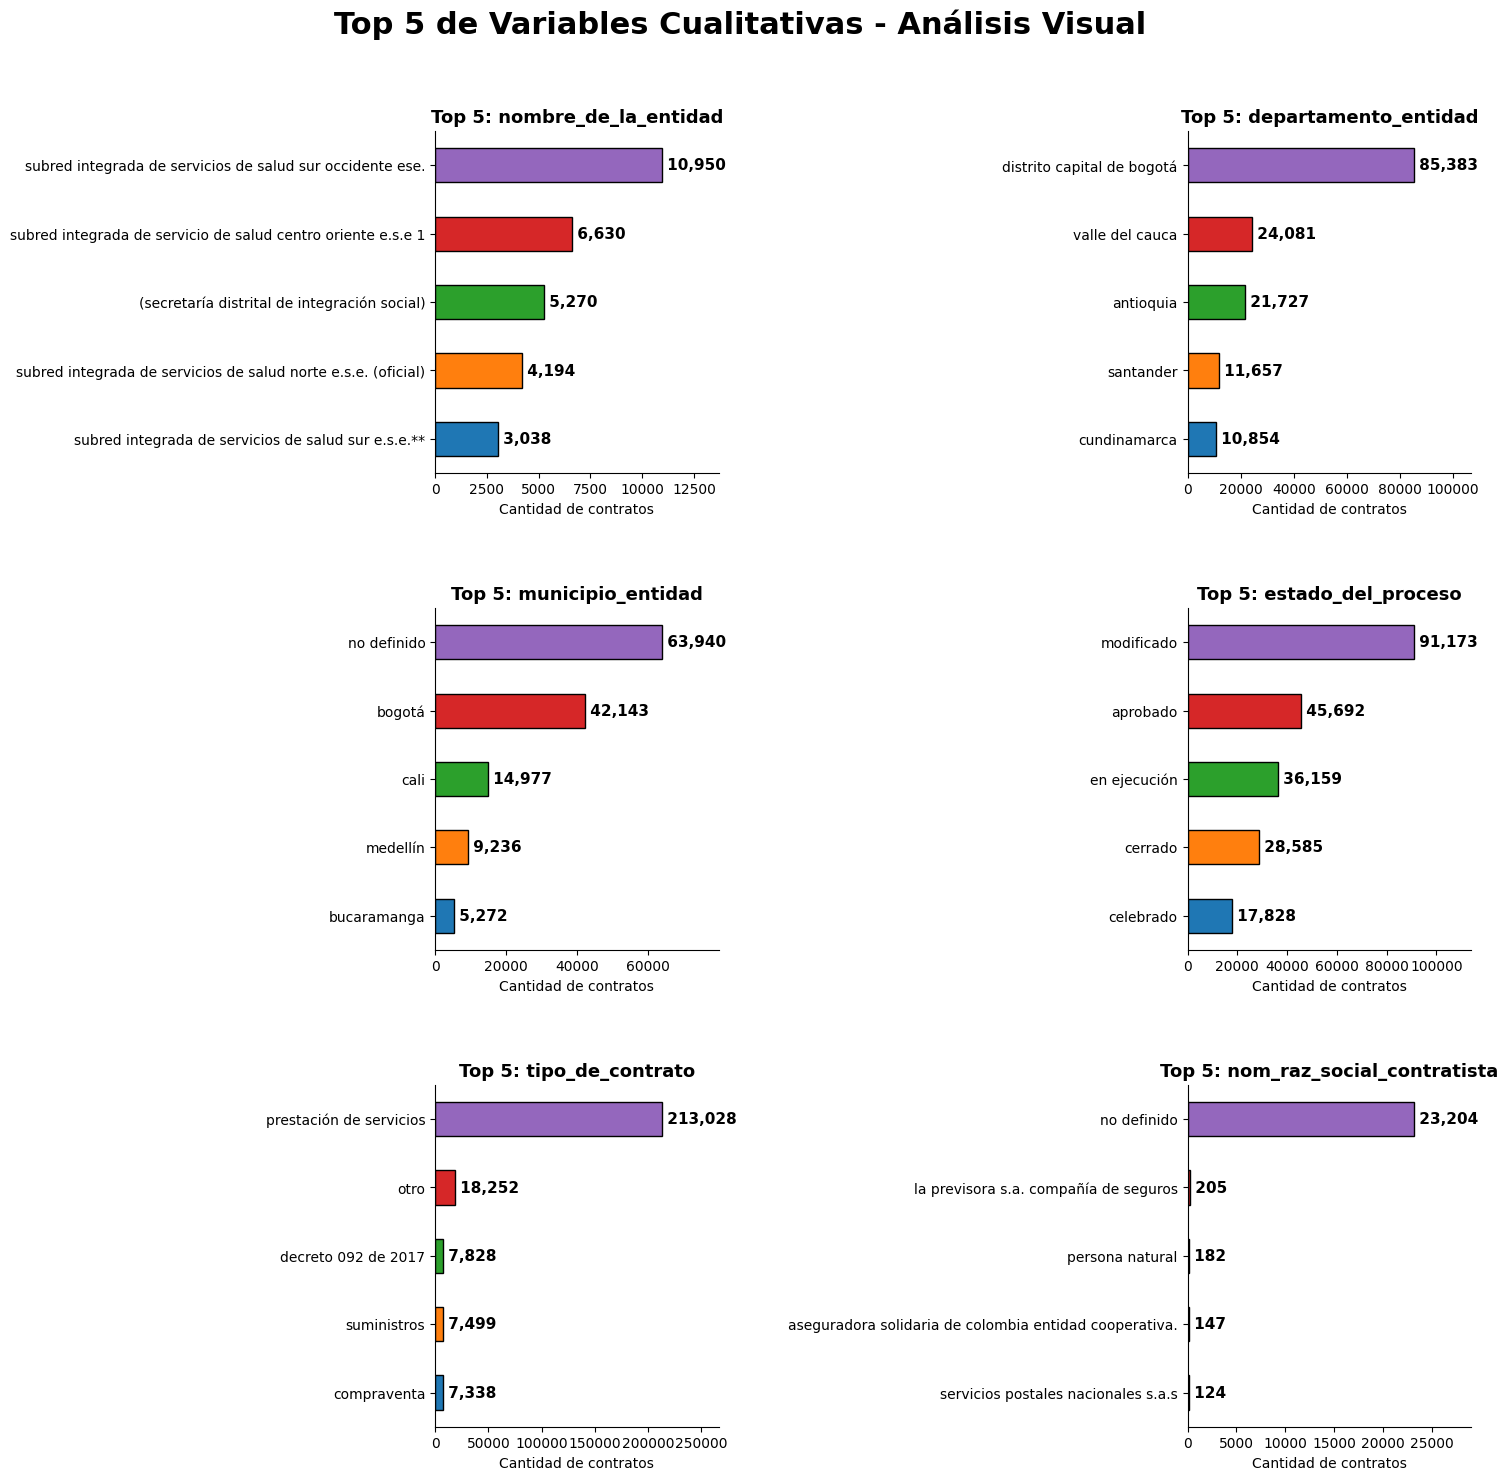

In [28]:
import matplotlib.pyplot as plt
import math

# 1. Configuración de variables y grid
vars_cualitativas = [
    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 
    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'
]

cols_grid = 2
rows_grid = math.ceil(len(vars_cualitativas) / cols_grid)

# Paleta de colores
colores_paleta = plt.cm.tab10.colors 

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    if col in df.columns:
        # Top 5 ordenado
        datos = df[col].value_counts().head(5).sort_values(ascending=True)

        ax = axes[i]
        
        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---
        datos.plot(
            kind='barh', 
            ax=ax, 
            color=colores_paleta[:len(datos)], 
            edgecolor='black'
        )

        ax.set_title(f'Top 5: {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cantidad de contratos')
        ax.set_ylabel('')

        # --- CAMBIO: Eliminamos ax.legend() ---
        # La leyenda ya no se mostrará.

        # Estética
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Etiquetas de datos al final de la barra (aquí ya está el número)
        max_valor = datos.max()
        for p in ax.patches:
            ancho = p.get_width()
            ax.annotate(
                f' {int(ancho):,}', 
                (ancho, p.get_y() + p.get_height()/2.),
                va='center', 
                ha='left', 
                fontsize=11, 
                fontweight='bold'
            )
        
        ax.set_xlim(0, max_valor * 1.25)

    else:
        axes[i].axis('off')

# Ajustes finales
plt.tight_layout(pad=5.0)
fig.suptitle(
    'Top 5 de Variables Cualitativas - Análisis Visual',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

plt.show()

### *Observación: Se realiza un cuadro de gráficas para mostrar las variables cualitativas en el TOP 5 de los que tienen mas frecuencia 1. La empresa con mas contratos en el SECOP es: subred integrada de servicios de salud centro oriente, 2. El departamento más dominante en contratos es la Distrito capital, 3. en el municipio prevalece el valor NO DEFINIDO quiere decir que al realizar la actualización de datos omiten ingresar esta información, 4. Los contratos son más frecuentes que sean modificados que celebrados o finalizados, 5. El tipo de contrato mas recurrente es del prestación de servicios, 6. el nombre de raiz social támbien pasa por alto y no es registrado en los procesos*

##### *Gráfica: Variables Temporales*

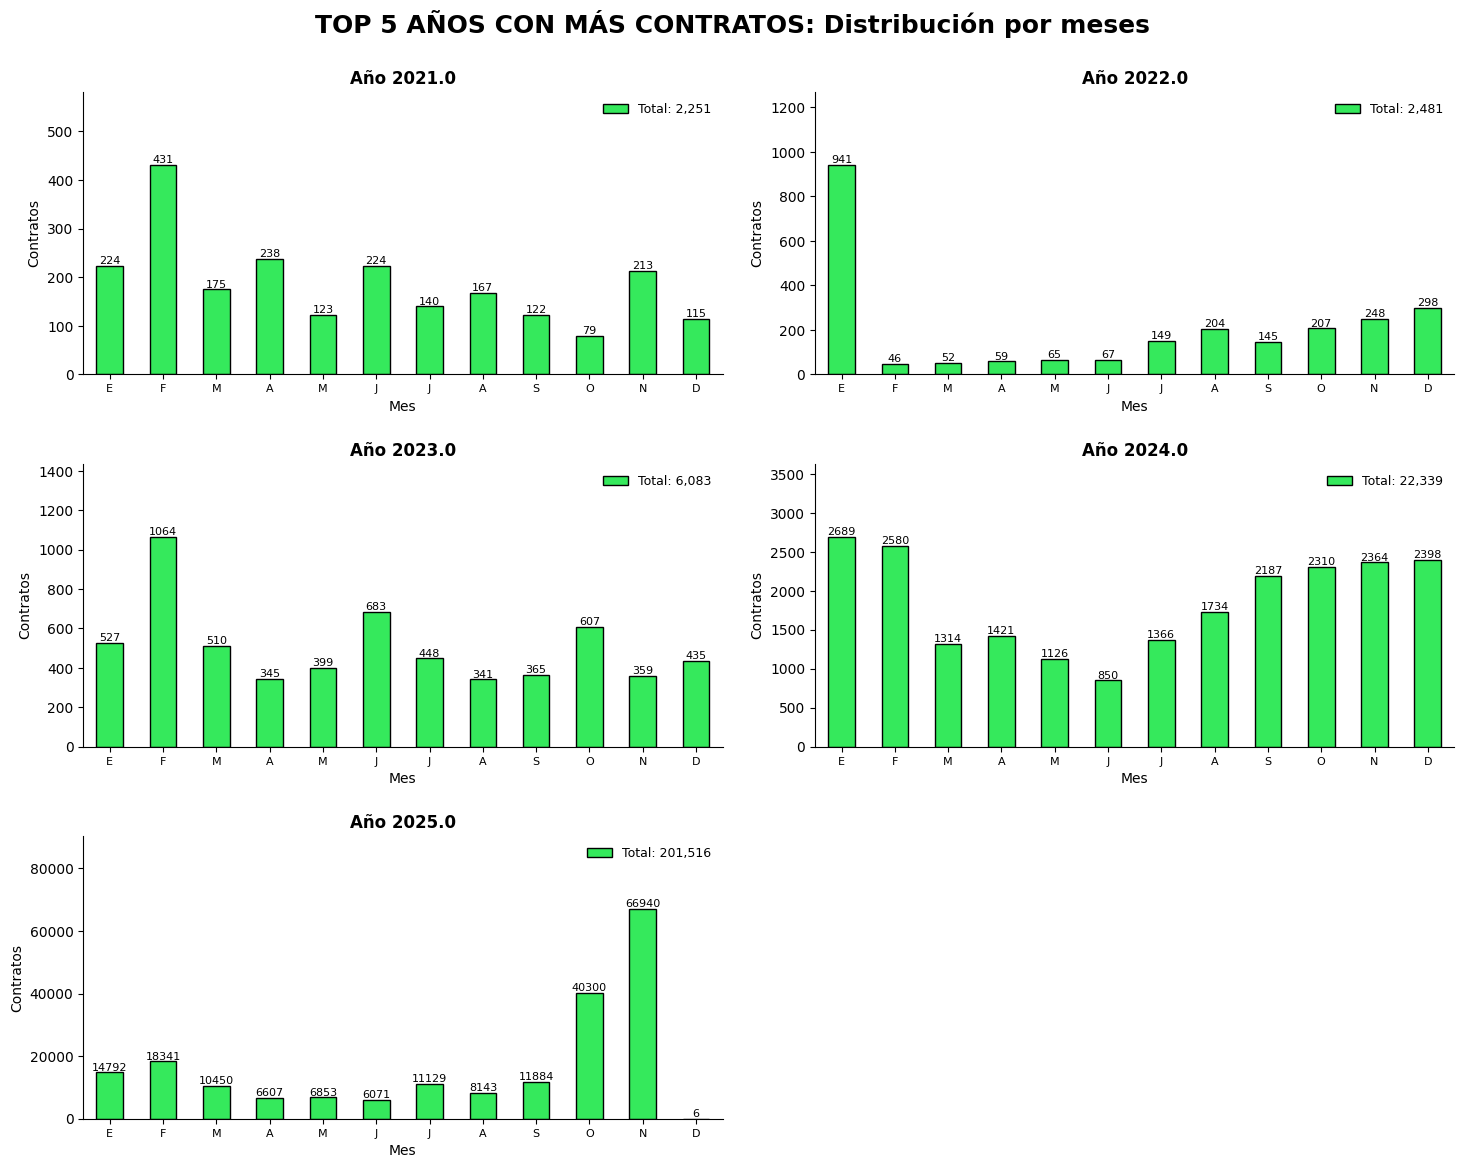

In [29]:
import math
import matplotlib.pyplot as plt

# 1. Aseguramos que el año y el mes estén extraídos
df['Año'] = df['fecha_de_firma_del_contrato'].dt.year
df['Mes'] = df['fecha_de_firma_del_contrato'].dt.month

# --- NUEVA LÓGICA: Filtrar los 5 años con más contratos ---
# Contamos contratos por año, ordenamos y tomamos los primeros 5 índices (años)
top_5_anios = df['Año'].value_counts().nlargest(5).index.tolist()

# Ordenamos los años cronológicamente para que el gráfico tenga sentido temporal
anios = sorted(top_5_anios) 
# ---------------------------------------------------------

cols = 2
rows = math.ceil(len(anios) / cols)

# 2. Lienzo (ajustado a los años filtrados)
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() 

# 3. Graficamos (solo iterará sobre los 5 seleccionados)
# 3. Graficamos
for i, anio in enumerate(anios):
    # Filtrar y agrupar
    datos_anio = df[df['Año'] == anio].groupby('Mes').size()
    datos_anio = datos_anio.reindex(range(1, 13), fill_value=0)
    
    # --- CALCULO DEL TOTAL PARA LA LEYENDA ---
    total_contratos = datos_anio.sum()
    # -----------------------------------------

    ax = axes[i]
    
    # Añadimos el parámetro label para la leyenda
    datos_anio.plot(
        kind='bar', 
        ax=ax, 
        color="#35e95c", 
        edgecolor='black',
        label=f'Total: {total_contratos:,}' # Formato con separador de miles
    )

    ax.set_title(f'Año {anio}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Contratos')
    ax.set_xticks(range(0, 12))
    ax.set_xticklabels(['E', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'],
                       rotation=0, fontsize=8)

    # --- ACTIVAR LA LEYENDA ---
    ax.legend(loc='upper right', fontsize=9, frameon=False)

    # Ajuste de escala
    max_anio = datos_anio.max()
    ax.set_ylim(0, max_anio * 1.35) # Aumenté un poco el margen para que la leyenda no tape las barras

    # Limpieza estética
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Etiquetas sobre las barras
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(str(int(p.get_height())),
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=8)

# 4. Apagar los cuadros vacíos (en este caso, 1 cuadro quedará vacío ya que 5 no es múltiplo de 3)
for j in range(len(anios), len(axes)):
    axes[j].axis('off')

fig.suptitle(
    'TOP 5 AÑOS CON MÁS CONTRATOS: Distribución por meses',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(pad=2.0)
plt.show()

### Observación: se realiza la creación de variables AÑO, MESES para identificar el top de los años donde se han registrado la mayor cantidad de contratos en el TOP: 1. 2025: 199.967, 2. 2024: 22.220, 3. 2023: 6.038, 4. 2022: 2.437, 5. 2018: 2.193. Conclusión: la participación en el SECOP ha incrementado gradualmente, támbien de debe al cumplimiento de las normas de contratación, resaltando transparencia, equidad e igualdad de oportunidades*

# --------------------------------------------------------------------------------------------------------

##### *Cambiar datos del dataset tipo dtype = 'str' sin tíldes para facilidad en la búsqueda*

In [30]:
mapeo_tildes = {
    'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
    'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U',
    'ü': 'u', 'Ü': 'U'
}

for col in df.columns:
    # Solo actuamos si la columna es de tipo texto (str)
    if df[col].dtype == 'str':
        # Aplicamos los reemplazos del diccionario
        for tildada, limpia in mapeo_tildes.items():
            df[col] = df[col].str.replace(tildada, limpia, regex=False)

##### *Resumen de valores nulos*

In [31]:
resumen = pd.DataFrame({
    'Nulos (NaN)': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Espacios Vacíos': df.apply(lambda x: (x == " ").sum()),
    'Tipo de Dato': df.dtypes
}).sort_values('Porcentaje (%)', ascending=False)
print(resumen[(resumen['Nulos (NaN)'] > 0) | (resumen['Espacios Vacíos'] > 0)])

                             Nulos (NaN)  Porcentaje (%)  Espacios Vacíos  \
fecha_inicio_ejecuci_n             75269           27.67                0   
Año                                32993           12.13                0   
fecha_de_firma_del_contrato        32993           12.13                0   
Mes                                32993           12.13                0   
fecha_fin_ejecuci_n                26847            9.87                0   
objeto_del_proceso                     1            0.00                0   
numero_de_proceso                      2            0.00                0   
nom_raz_social_contratista             2            0.00                0   
documento_proveedor                    4            0.00                0   

                               Tipo de Dato  
fecha_inicio_ejecuci_n       datetime64[us]  
Año                                 float64  
fecha_de_firma_del_contrato  datetime64[us]  
Mes                                 float64  

##### *Imputacion de datos con los valores de la fecha de la firma del contrato, para llenar datos de la fecha de inicio, que muchas veces suele ser la misma del inicio, luego usando la moda para llenar los valores NAN de las fechas que en ambas columnas son vacias*

In [32]:
# 1. Cruce entre columnas

#Llenar los vacíos de la fecha de inicio con los valores de la firma del contrato
#df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].combine_first(df['fecha_de_firma_del_contrato'])
#funciona a la inversa para llenar los datos
#df['fecha_de_firma_del_contrato'] = df['fecha_de_firma_del_contrato'].combine_first(df['fecha_inicio_ejecucion'])

# 2. Usamos la moda aquí como ejemplo por ser lo más frecuente
#moda_fecha = df['fecha_inicio_ejecucion'].mode()[0]

#df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].fillna(moda_fecha)
#df['fecha_de_firma_del_contrato'] = df['fecha_de_firma_del_contrato'].fillna(moda_fecha)


In [33]:
# 3. Aqui se esta creando el imputer con la moda.
imputer_str = SimpleImputer(strategy="most_frequent")

# aplicar el imputer a las columnas con NAN 
#df["numero_de_proceso"] = imputer_str.fit_transform(df[["numero_de_proceso"]]).ravel()
#df["nom_raz_social_contratista"] = imputer_str.fit_transform(df[["nom_raz_social_contratista"]]).ravel()
#df["documento_proveedor"] = imputer_str.fit_transform(df[["documento_proveedor"]]).ravel()
#df["objeto_del_proceso"] = imputer_str.fit_transform(df[["objeto_del_proceso"]]).ravel()


In [34]:
df.head(5)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor,Año,Mes
0,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4416408,224-2015 contrato de prestacion de servicio,1500000,anderson antonio urbano ruales,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,18130744,2015.0,11.0
1,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418304,227-2015 contrato de prestacion de servicio,1500000,juan sebastian buitrago,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,1094885358,2015.0,11.0
2,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418312,230-2015 contrato de prestacion de servicio,1400000,julian mauricio ocampo,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,4375686,2015.0,11.0
3,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418338,234-2015 contrato de prestacion de servicio,1500000,juan pablo castaneda daza,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,1.097.390.531,2015.0,11.0
4,territorial,50000005,quindio - indeportes quindio,801001532,quindio,circasia,terminado sin liquidar,contratacion directa (ley 1150 de 2007),prestar los servicios de apoyo a la gestion en...,prestar los servicios de apoyo a la gestion en...,prestacion de servicios,2016-04-04,2016-04-04,2016-08-04,16-12-4954064,contrato de prestacion de servicios 045 de 2016,4200000,erick alberto gamro vega,https://www.contratos.gov.co/consultas/detalle...,secopi,cedula de ciudadania,7603987,2016.0,4.0


In [35]:
df.info()

<class 'pandas.DataFrame'>
Index: 272015 entries, 0 to 299999
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   nivel_entidad                272015 non-null  str           
 1   codigo_entidad_en_secop      272015 non-null  str           
 2   nombre_de_la_entidad         272015 non-null  str           
 3   nit_de_la_entidad            272015 non-null  str           
 4   departamento_entidad         272015 non-null  str           
 5   municipio_entidad            272015 non-null  str           
 6   estado_del_proceso           272015 non-null  str           
 7   modalidad_de_contrataci_n    272015 non-null  str           
 8   objeto_a_contratar           272015 non-null  str           
 9   objeto_del_proceso           272014 non-null  str           
 10  tipo_de_contrato             272015 non-null  str           
 11  fecha_de_firma_del_contrato  239022 non-nu

In [36]:
df.describe(include='number')

,valor_contrato,Año,Mes
count,2.720150e+05,239022.000000,239022.000000
mean,7.672337e+08,2024.662801,7.563216
std,4.523751e+10,1.121871,3.672125
min,0.000000e+00,2007.000000,1.000000
25%,6.300000e+06,2025.000000,4.000000
50%,1.643790e+07,2025.000000,9.000000
75%,4.309870e+07,2025.000000,11.000000
max,9.000000e+12,2026.000000,12.000000


In [37]:
#comprobamos cuantas filas quedan
df.shape[0]

272015

OBSERVACION: El dataset nos quedo con 259.823 lo cual nos dice que existian cerca de 28.000 contratos que a la fecha no se habian aprobado y otros que tenian valor de contrato en $0 pesos, todos estos se descartaron del dataset. existen  7528  filas que no tienen fecha de inicio de ejecucion, pero si tenian fecha de firma de contrato, por lo cual se les imputo el valor de la columna.




#debemos tenr metricas de calsificacion y variar el treshold

HISTOGRAMAS DE FRECUENCIAS PARA LAS VARIABLES TEMPORALES

In [38]:
df['fecha_de_firma_del_contrato'].dtype

dtype('<M8[us]')